# Using neural networks for function fitting.

**An very brief ML introduction with the concepts from the lecture**

We are going to answer one question in three different ways:

> Given a cloud of noisy measurements $(x_i, y_i)$, how do we recover the function that produced them?

Firstly, we will entirely solve this using **linear regression**, and then re-solve that *same* problem with machine learning machinery. First by gradient descent (no neural nets), then introduce a neural network as a model. Once the machinery is fully checked we use it with a function that linear regression *cannot* fit: $f(x) = \sin(x)$.

| Part | Problem | Method | Focus |
|---|---|---|---|
| 1 | $f(x) = 2x + 1$ | least squares → gradient descent → PyTorch | loss, gradients, learning rate |
| 2 | $f(x) = 2x + 1$ | multi-layer perceptron (MLP) | architecture, hidden layers, activations |
| 3 | $f(x) = \sin(x)$ | polynomial features vs. MLP | nonlinearity matters, learned features |
| 4 | both | stress testing ML | extrapolation, overfitting |

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Fix the random seeds so that every run of this notebook gives the same figures.
torch.manual_seed(0)
rng = np.random.default_rng(0)

# One consistent visual language for the whole notebook:
# each colour always means the same thing, in every single plot.
C_DATA = "#8a8983"   # the observed data  (neutral grey: data is not a model)
C_TRUE = "#0b0b0b"   # the true function we are trying to recover
C_LIN  = "#2a78d6"   # linear regression, closed-form solution
C_GD   = "#eb6834"   # the same model, fitted by gradient descent
C_MLP  = "#1baf7a"   # multi-layer perceptron
C_POLY = "#eda100"   # polynomial features

plt.rcParams.update({
    "figure.figsize": (7, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.edgecolor": "#c9c8c4", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "lines.linewidth": 2.0, "font.size": 11, "legend.frameon": False,
})

print("PyTorch version:", torch.__version__)

PyTorch version: 2.7.0


---
## What "fitting" actually means

Every supervised learning problem in this notebook has three ingredients.

**1. Data.** $N$ pairs $(x_i, y_i)$. We assume they were produced by some unknown function plus measurement noise:

$$ y_i = f(x_i) + \varepsilon_i $$

**2. A model.** A family of candidate functions $f_\theta$ controlled by parameters $\theta$. A straight line is the family $f_\theta(x) = wx + b$ with $\theta = (w, b)$: two numbers, and every choice of them names one particular line.

**3. A loss.** A single number saying how badly a given $\theta$ explains the data. Throughout we use the **mean squared error**:

$$ L(\theta) \;=\; \frac{1}{N}\sum_{i=1}^{N}\bigl(f_\theta(x_i) - y_i\bigr)^2 $$

**Fitting** = finding the $\theta$ that makes $L(\theta)$ as small as possible.

What we will change in the different methods is (a) how rich the model family is, and (b) how we search for the minimum. 

---
# 1. A problem we can already solve (and that doesn't need ML)

## 1.1 The data

Let the truth be a straight line, $f(x) = 2x + 1$, observed through noise. In real life we never see the black dashed line; we only ever see the grey dots and have to guess the line.

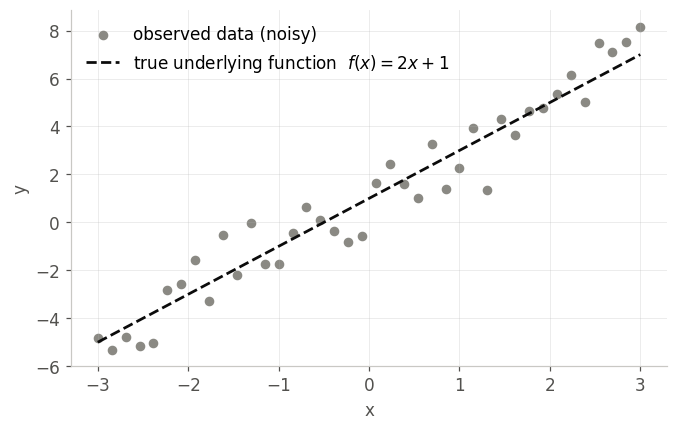

In [4]:
def true_line(x):
    return 2.0 * x + 1.0

N = 40
x_train = np.linspace(-3, 3, N)
y_train = true_line(x_train) + rng.normal(0.0, 1.0, N)   # add measurement noise

x_grid = np.linspace(-3, 3, 200)   # a fine grid, only used for drawing curves

fig, ax = plt.subplots()
ax.scatter(x_train, y_train, s=28, color=C_DATA, label="observed data (noisy)")
ax.plot(x_grid, true_line(x_grid), color=C_TRUE, ls="--", lw=1.8,
        label="true underlying function  $f(x)=2x+1$")
ax.set(xlabel="x", ylabel="y")
ax.legend(loc="upper left")
plt.show()

## 1.2 The exact answer: least squares

A *linear* model does not need to search for solutions, we can directly write the model as a matrix product,

$$
\underbrace{\begin{pmatrix} y_1 \\ \vdots \\ y_N \end{pmatrix}}_{\mathbf{y}}
\;\approx\;
\underbrace{\begin{pmatrix} 1 & x_1 \\ \vdots & \vdots \\ 1 & x_N \end{pmatrix}}_{X}
\underbrace{\begin{pmatrix} b \\ w \end{pmatrix}}_{\theta},
$$

set the derivative of the loss to zero, and we can get the **normal equations**:

$$ \theta^\star = (X^\top X)^{-1} X^\top \mathbf{y} $$

This is our gold standard (and baseline). In this particular case, we cannot really do any better since the underlying function is linear.

In [9]:
X = np.stack([np.ones_like(x_train), x_train], axis=1)     # design matrix, shape (N, 2)
theta_star, *_ = np.linalg.lstsq(X, y_train, rcond=None)   # solves the normal equations
b_star, w_star = theta_star

def mse(pred, target):
    return float(np.mean((np.asarray(pred) - np.asarray(target)) ** 2))

y_fit_lin = b_star + w_star * x_train

print(f"least squares solution :  w = {w_star:.4f},  b = {b_star:.4f}")
print(f"true parameters      :  w = 2.0000,  b = 1.0000")
print(f"solution MSE         :  {mse(y_fit_lin, y_train):.4f}")

least squares solution :  w = 2.0658,  b = 1.0030
true parameters      :  w = 2.0000,  b = 1.0000
solution MSE         :  0.8557


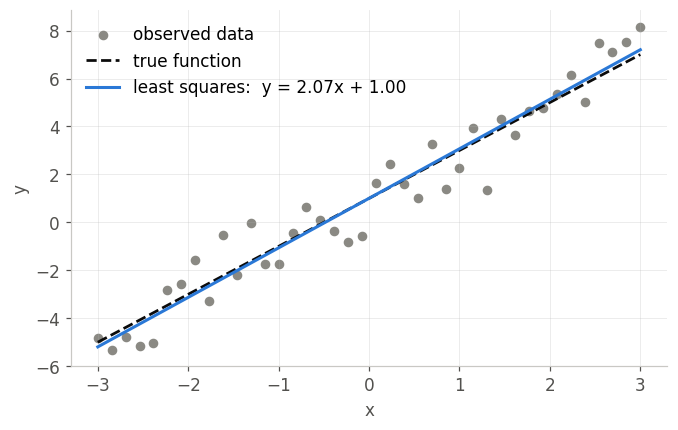

In [10]:
fig, ax = plt.subplots()
ax.scatter(x_train, y_train, s=28, color=C_DATA, label="observed data")
ax.plot(x_grid, true_line(x_grid), color=C_TRUE, ls="--", lw=1.8, label="true function")
ax.plot(x_grid, b_star + w_star * x_grid, color=C_LIN,
        label=f"least squares:  y = {w_star:.2f}x + {b_star:.2f}")
ax.set(xlabel="x", ylabel="y")
ax.legend(loc="upper left")
plt.show()

Notice that the fit does **not** land exactly on $w=2, b=1$, and that is what we realistically can expect with only 40 noisy samples. We could add more points for a better fit.

## 1.3 The same answer, found by walking downhill (gradient descent, an ML staple)

Let us consider that we do not have the normal equations, that means that we need to **search** for the solution, and the search algorithm behind modern machine learning is **gradient descent**:

> Stand at some $\theta$. Compute the slope of the loss. Take a small step in the downhill direction. Repeat.

In symbols, with **learning rate** $\eta$:

$$ \theta \;\leftarrow\; \theta - \eta \, \nabla_\theta L(\theta) $$

For our line, the two derivatives are easy to write by hand. With residual $r_i = (wx_i + b) - y_i$:

$$ \frac{\partial L}{\partial w} = \frac{2}{N}\sum_i r_i\,x_i, \qquad
   \frac{\partial L}{\partial b} = \frac{2}{N}\sum_i r_i $$

Implementing this directly (ML libraries typically do this under the hood)

In [15]:
w, b = 0.0, 0.0        # start from a deliberately bad guess: the flat line y = 0
eta  = 0.05            # learning rate: how big a step we take downhill
n_steps = 200

history, path = [], []
for step in range(n_steps):
    y_pred = w * x_train + b
    resid  = y_pred - y_train

    loss   = np.mean(resid ** 2)
    grad_w = 2.0 * np.mean(resid * x_train)   # dL/dw
    grad_b = 2.0 * np.mean(resid)             # dL/db

    history.append(loss)
    path.append((w, b))

    w -= eta * grad_w        # <-- the entire learning algorithm, right here
    b -= eta * grad_b

    if step % 40 == 0:
        print(f"step {step:3d}   loss = {loss:6.3f}   w = {w:6.3f}   b = {b:6.3f}")

print(f"\ngradient descent              :  w = {w:.4f},  b = {b:.4f}")
print(f"linear method (least squares) :  w = {w_star:.4f},  b = {b_star:.4f}   <- the same answer")

step   0   loss = 15.320   w =  0.652   b =  0.100
step  40   loss =  0.856   w =  2.066   b =  0.990
step  80   loss =  0.856   w =  2.066   b =  1.003
step 120   loss =  0.856   w =  2.066   b =  1.003
step 160   loss =  0.856   w =  2.066   b =  1.003

gradient descent              :  w = 2.0658,  b = 1.0030
linear method (least squares) :  w = 2.0658,  b = 1.0030   <- the same answer


It found the same answer. Let us watch it happen. Because the model has only two parameters, we can draw the **loss landscape** $L(w, b)$ as a contour map and trace the path gradient descent takes across it.

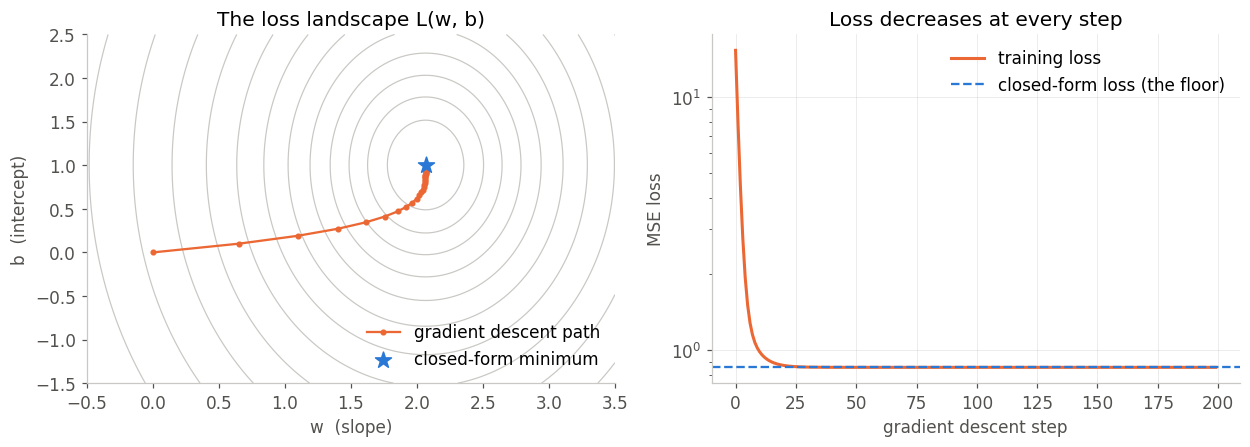

In [16]:
# Evaluate the loss on a grid of (w, b) values, so we can see the surface we are descending.
ws, bs = np.linspace(-0.5, 3.5, 120), np.linspace(-1.5, 2.5, 120)
WW, BB = np.meshgrid(ws, bs)
LL = np.mean((WW[..., None] * x_train + BB[..., None] - y_train) ** 2, axis=-1)
path = np.array(path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))

cs = ax1.contour(WW, BB, LL, levels=np.geomspace(LL.min() + 1e-3, LL.max(), 14),
                 colors="#c9c8c4", linewidths=0.8)
ax1.plot(path[:, 0], path[:, 1], color=C_GD, marker="o", ms=3, lw=1.5,
         label="gradient descent path")
ax1.scatter([w_star], [b_star], s=120, marker="*", color=C_LIN, zorder=5,
            label="closed-form minimum")
ax1.set(xlabel="w  (slope)", ylabel="b  (intercept)", title="The loss landscape L(w, b)")
ax1.grid(False); ax1.legend(loc="lower right")

ax2.plot(history, color=C_GD, label="training loss")
ax2.axhline(mse(y_fit_lin, y_train), color=C_LIN, ls="--", lw=1.5,
            label="closed-form loss (the floor)")
ax2.set(xlabel="gradient descent step", ylabel="MSE loss", yscale="log",
        title="Loss decreases at every step")
ax2.legend()
plt.tight_layout(); plt.show()

Two things worth staring at:

* The path runs **perpendicular to the contour lines** — that is what "steepest descent" means geometrically.
* The loss flattens out at the linear method value. It does not go to zero, because the data is noisy and no line can pass through all 40 points. **A loss that stops decreasing is not a failure; it usually means you have hit the noise floor.**

> **Try it yourself.** Re-run the cell above with `eta = 0.5`, and again with `eta = 0.001`. Too large and the steps overshoot and the path oscillates or diverges; too small and it crawls and never arrives in 200 steps. This shows how sensitive optimisation is to the learning rate (i.e. the step of the gradient descent)

## 1.4 The same thing again, in PyTorch

Writing gradients by hand works well for simple functions but it can get arbitrarily hard. PyTorch's job is to compute them for us: we write only the *forward* computation, and **autograd** differentiates it automatically.

The code below is the standard PyTorch training loop. 

```
prediction = model(x)          # 1. forward pass
loss       = loss_fn(pred, y)  # 2. how wrong are we?
opt.zero_grad()                # 3. clear the previous gradients
loss.backward()                # 4. autograd: compute dL/dtheta for every parameter
opt.step()                     # 5. take one step downhill
```

Note that `nn.Linear(1, 1)` — a single layer with one input and one output — **is** the model $wx+b$. It is already a neural network; it just happens to be the smallest possible one, with no hidden layer.

In [17]:
def T(a):
    # Convert a 1-D NumPy array into the (N, 1) float32 tensor PyTorch expects.
    return torch.tensor(np.asarray(a, dtype=np.float32).reshape(-1, 1))

xt, yt = T(x_train), T(y_train)

model_lin = nn.Linear(1, 1)                                  # exactly 2 parameters: w and b
loss_fn   = nn.MSELoss()
opt       = torch.optim.SGD(model_lin.parameters(), lr=0.05)  # same eta as before

torch_history = []
for step in range(200):
    pred = model_lin(xt)             # 1. forward pass
    loss = loss_fn(pred, yt)         # 2. measure the error
    opt.zero_grad()                  # 3. reset gradients
    loss.backward()                  # 4. autograd fills in .grad for w and b
    opt.step()                       # 5. step downhill
    torch_history.append(loss.item())

w_torch = model_lin.weight.item()
b_torch = model_lin.bias.item()
print(f"PyTorch     :  w = {w_torch:.4f},  b = {b_torch:.4f}")
print(f"hand-written:  w = {w:.4f},  b = {b:.4f}")
print(f"closed form :  w = {w_star:.4f},  b = {b_star:.4f}")
print("\nThree different routes, one destination.")

PyTorch     :  w = 2.0658,  b = 1.0030
hand-written:  w = 2.0658,  b = 1.0030
closed form :  w = 2.0658,  b = 1.0030

Three different routes, one destination.


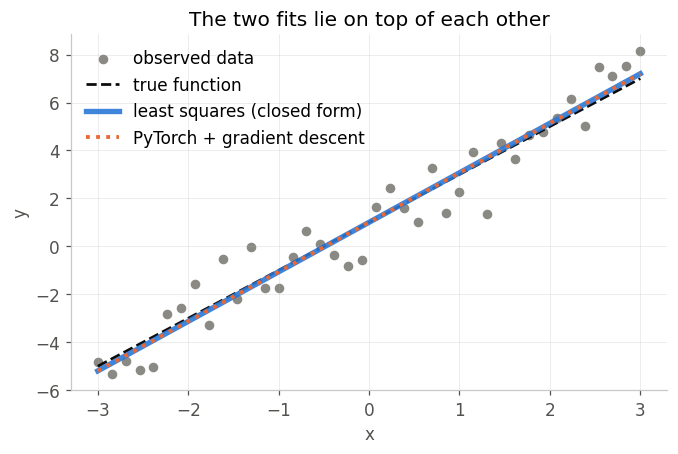

In [ ]:
fig, ax = plt.subplots()
ax.scatter(x_train, y_train, s=28, color=C_DATA, label="observed data")
ax.plot(x_grid, true_line(x_grid), color=C_TRUE, ls="--", lw=1.8, label="true function")
ax.plot(x_grid, b_star + w_star * x_grid, color=C_LIN, lw=3.5, alpha=0.9,
        label="least squares (closed form)")
ax.plot(x_grid, b_torch + w_torch * x_grid, color=C_GD, ls=":", lw=2.5,
        label="PyTorch + gradient descent")
ax.set(xlabel="x", ylabel="y")
ax.legend(loc="upper left")
plt.show()

> ### Takeaway from Part 1
> Machine learning gave the *same* answer, more slowly, with a learning rate to tune. What a NN approach gives is**generality**: gradient descent never used the fact that the model was a line. Swap in a model with a million parameters and the same methodology can be applied

---
# 2. The same problem, with a neural network

## 2.1 What an MLP is

A **multi-layer perceptron** alternates linear maps with a simple nonlinear function applied element-wise. With one hidden layer of width $H$:

$$ f_\theta(x) \;=\; \underbrace{W_2}_{1 \times H} \, \sigma\!\bigl(\underbrace{W_1}_{H \times 1} x + b_1 \bigr) \; + \; b_2 $$

As a pipeline:

```
   x  ──►  Linear(1 → H)  ──►  tanh  ──►  Linear(H → 1)  ──►  prediction
          "H different              "bend                "mix them
           straight lines"           each one"            back together"
```

The activation $\sigma$ — here $\tanh$  is necessary to capture the nonlinearity. Without it,

$$ W_2(W_1 x + b_1) + b_2 = (W_2 W_1)x + (W_2 b_1 + b_2) = \tilde{w}x + \tilde{b} $$

and the whole network collapses back into a single straight line. **The nonlinearity is the reason we might want to go deeper in the networks.**

In [22]:
def make_mlp(width=32, depth=1, activation=nn.Tanh):
    # A 1-D -> 1-D MLP with `depth` hidden layers, each of `width` neurons.
    layers = [nn.Linear(1, width), activation()]
    for _ in range(depth - 1):
        layers += [nn.Linear(width, width), activation()]
    layers += [nn.Linear(width, 1)]
    return nn.Sequential(*layers)


def train(model, x, y, epochs=2000, lr=1e-2, snapshot_at=(), x_snap=None):
    # The standard training loop. Returns the loss history and optional snapshots.
    opt, loss_fn = torch.optim.Adam(model.parameters(), lr=lr), nn.MSELoss()
    history, snaps = [], {}
    for ep in range(epochs + 1):
        if ep in snapshot_at:                       # record the fit as it evolves
            with torch.no_grad():
                snaps[ep] = model(x_snap).numpy().ravel()
        loss = loss_fn(model(x), y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        history.append(loss.item())
    return np.array(history), snaps


def predict(model, x):
    # Evaluate a trained model on a NumPy array, returning a NumPy array.
    with torch.no_grad():
        return model(T(x)).numpy().ravel()


def n_params(model):
    return sum(p.numel() for p in model.parameters())

# We switch from plain SGD to Adam here. Adam adapts the step size per parameter;
# for anything beyond a straight line it is far more forgiving to tune.
print("Helpers defined.")

Helpers defined.


## 2.2 Pointing it at the straight line

We need one more ingredient based on the course material: a **test set**. These are fresh points from the same noisy process that the model never sees during training. Training loss says how well the model memorised; test loss will show if it has learned.

In [25]:
# Fresh data from the same process, held out: the model never trains on this.
x_te_lin = np.sort(rng.uniform(-3, 3, 200))
y_te_lin = true_line(x_te_lin) + rng.normal(0.0, 1.0, 200)

torch.manual_seed(0)
mlp_line = make_mlp(width=32)
hist_line, _ = train(mlp_line, xt, yt, epochs=2000, lr=0.01)

lin_train = mse(y_fit_lin, y_train)
lin_test  = mse(b_star + w_star * x_te_lin, y_te_lin)
mlp_test  = mse(predict(mlp_line, x_te_lin), y_te_lin)

print(f"{'model':<26}{'params':>8}{'train MSE':>12}{'test MSE':>11}")
print(f"{'linear regression':<26}{2:>8}{lin_train:>12.4f}{lin_test:>11.4f}")
print(f"{'MLP (width 32)':<26}{n_params(mlp_line):>8}{hist_line[-1]:>12.4f}{mlp_test:>11.4f}")

model                       params   train MSE   test MSE
linear regression                2      0.8557     0.9707
MLP (width 32)                  97      0.5563     1.1385


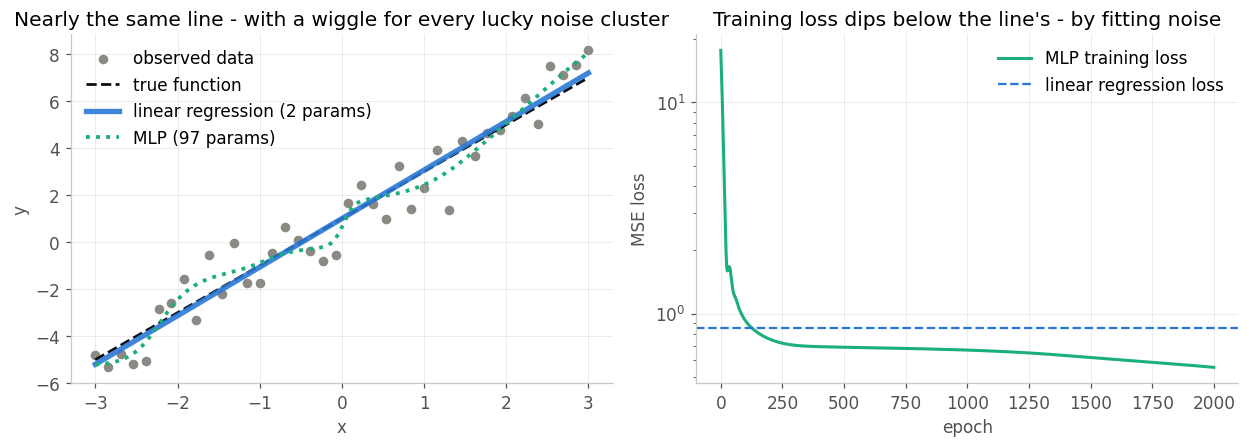

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))

ax1.scatter(x_train, y_train, s=28, color=C_DATA, label="observed data")
ax1.plot(x_grid, true_line(x_grid), color=C_TRUE, ls="--", lw=1.8, label="true function")
ax1.plot(x_grid, b_star + w_star * x_grid, color=C_LIN, lw=3.5, alpha=0.9,
         label="linear regression (2 params)")
ax1.plot(x_grid, predict(mlp_line, x_grid), color=C_MLP, ls=":", lw=2.5,
         label=f"MLP ({n_params(mlp_line)} params)")
ax1.set(xlabel="x", ylabel="y")
ax1.legend(loc="upper left")

ax2.plot(hist_line, color=C_MLP, label="MLP training loss")
ax2.axhline(mse(y_fit_lin, y_train), color=C_LIN, ls="--", lw=1.5,
            label="linear regression loss")
ax2.set(xlabel="epoch", ylabel="MSE loss", yscale="log")
ax2.legend()
plt.tight_layout(); plt.show()

Note here that the MLP has the **lower training loss**, and we are allowing it to be nonlinear, which is the reason for the wiggles in the figure. This allows it to beat beat the closed-form optimum. The MLP used parameters to bend slightly toward every accidental cluster of noise.

And on data it has never seen, note that it is **worse** than the two-parameter line.

> ### Takeaway from Part 2
> Those extra wiggles were fitted to the noise, and the noise in the test set is different noise. Chasing it is called **overfitting**.
>
> *More capacity is not more accuracy.* If a linear model fits your problem, then it is best and that's the reason why we should use strong baselines! It is good practice to **report loss on held-out data** the training loss alone might not tell the full story.
>
> So when *is* the extra capacity worth it? When linear methods don't do very well.

---
# 3. A function linear regression cannot fit

## 3.1 Where the straight line fails

Same experiment but based on the function: $f(x) = \sin(x)$ on $[-\pi, \pi]$, with a little noise.

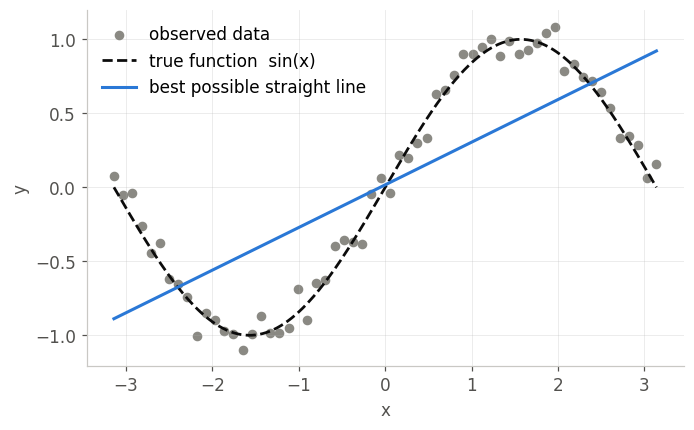

linear model MSE on sin data: 0.2177


In [28]:
N_sin = 60
x_sin = np.linspace(-np.pi, np.pi, N_sin)
y_sin = np.sin(x_sin) + rng.normal(0.0, 0.08, N_sin)

xs_grid = np.linspace(-np.pi, np.pi, 300)
xs_t, ys_t = T(x_sin), T(y_sin)

# Fit the best possible straight line to it, using the exact formula from Part 1.
X_sin = np.stack([np.ones_like(x_sin), x_sin], axis=1)
theta_sin, *_ = np.linalg.lstsq(X_sin, y_sin, rcond=None)
lin_sin = theta_sin[0] + theta_sin[1] * xs_grid

fig, ax = plt.subplots()
ax.scatter(x_sin, y_sin, s=28, color=C_DATA, label="observed data")
ax.plot(xs_grid, np.sin(xs_grid), color=C_TRUE, ls="--", lw=1.8, label="true function  sin(x)")
ax.plot(xs_grid, lin_sin, color=C_LIN, label="best possible straight line")
ax.set(xlabel="x", ylabel="y")
ax.legend(loc="upper left")
plt.show()

print(f"linear model MSE on sin data: {mse(theta_sin[0] + theta_sin[1] * x_sin, y_sin):.4f}")

This is **underfitting**, this means that the model is too simple. The failure is in the **model family**: no straight line is a sine, so no amount of better optimisation can help. When the model underfits we need a richer model.

## 3.2 Fix attempt 1: change the features, keep the linear regression

Here is a trick worth knowing before reaching for a network. Fit

$$ f_\theta(x) = \theta_0 + \theta_1 x + \theta_2 x^2 + \dots + \theta_d x^d $$

This is *still linear regression* because the model is still linear **in the parameters** $\theta$. All we changed is the columns of the design matrix: instead of $[1, x]$ we hand it $[1, x, x^2, \dots, x^d]$. Those columns **features**, and choosing them by hand is called **feature engineering**.

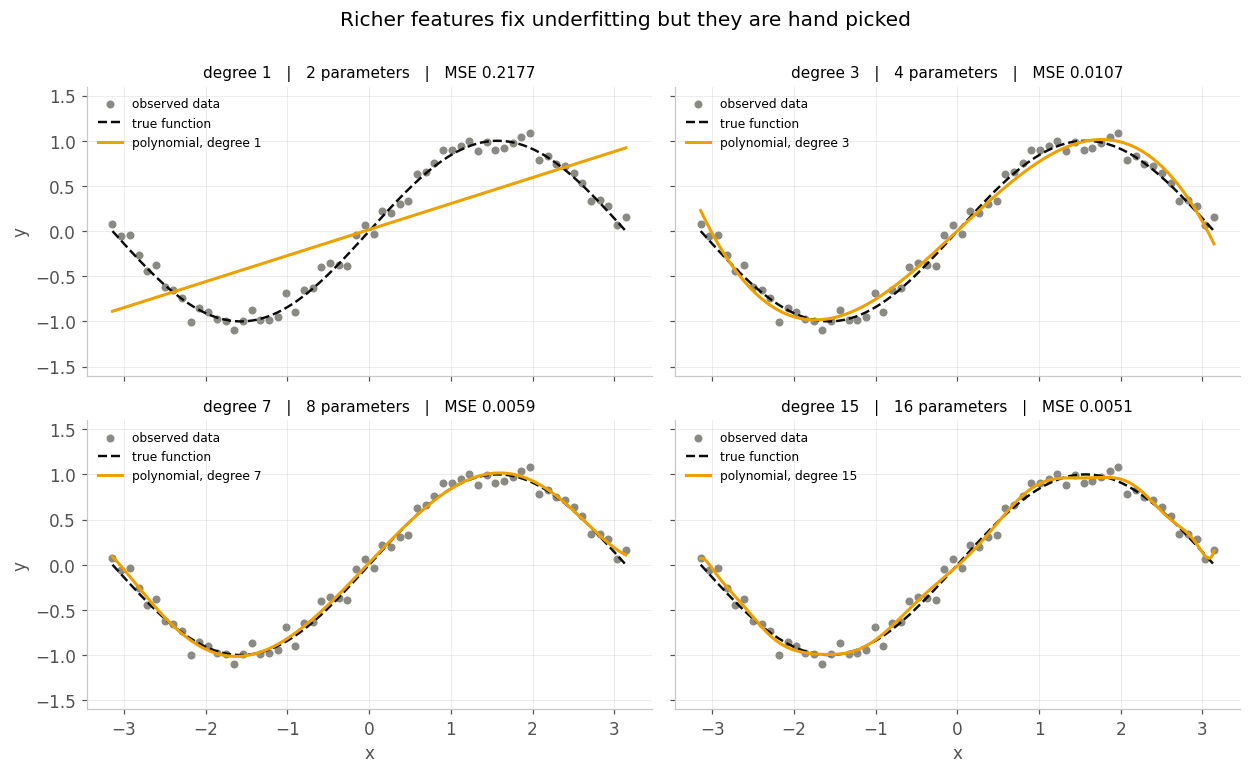

In [31]:
degrees = [1, 3, 7, 15]
fig, axes = plt.subplots(2, 2, figsize=(11.5, 7), sharex=True, sharey=True)

for ax, d in zip(axes.ravel(), degrees):
    coef = np.polyfit(x_sin, y_sin, d)          # closed-form least squares, degree d
    ax.scatter(x_sin, y_sin, s=18, color=C_DATA, label="observed data")
    ax.plot(xs_grid, np.sin(xs_grid), color=C_TRUE, ls="--", lw=1.6, label="true function")
    ax.plot(xs_grid, np.polyval(coef, xs_grid), color=C_POLY,
            label=f"polynomial, degree {d}")
    ax.set_title(f"degree {d}   |   {d + 1} parameters   |   "
                 f"MSE {mse(np.polyval(coef, x_sin), y_sin):.4f}", fontsize=10)
    ax.set_ylim(-1.6, 1.6)
    ax.legend(loc="upper left", fontsize=8)

for ax in axes[1]:
    ax.set_xlabel("x")
for ax in axes[:, 0]:
    ax.set_ylabel("y")
fig.suptitle("Richer features fix underfitting but they are hand picked", y=1.0)
plt.tight_layout(); plt.show()

Degree 7 is excellent but we had to supply the *knowledge* that powers of $x$ were the right building blocks, which is not surprising considering a Taylor expansion. For a 1-D toy problem we are ok, but for complex physical problems, this is much harder.

## 3.3 Let the network discover its own features

The MLP's hidden layer builds features *for itself* by gradient descent. We supply only the raw $x$. Let us watch it learn, by taking snapshots of the fitted curve as training proceeds.

In [35]:
torch.manual_seed(0)
mlp_sin = make_mlp(width=32)
snap_epochs = (0, 100, 500, 2000, 8000)
hist_sin, snaps = train(mlp_sin, xs_t, ys_t, epochs=8000, lr=0.01,
                        snapshot_at=snap_epochs, x_snap=T(xs_grid))

print(f"parameters : {n_params(mlp_sin)}")
print(f"final MSE  : {hist_sin[-1]:.5f}")

parameters : 97
final MSE  : 0.00489


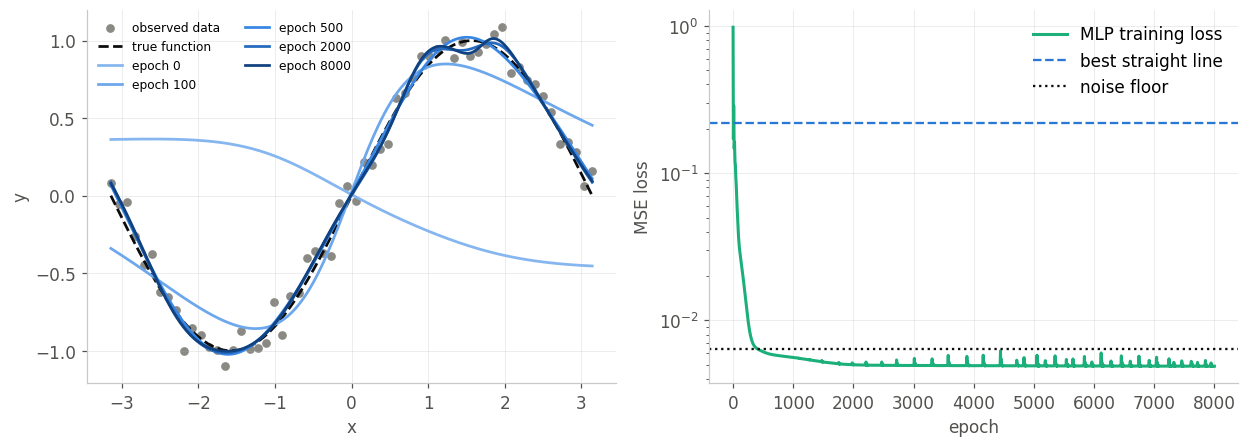

In [37]:
# Training progress is a *magnitude* (how far along we are), so it gets a single-hue
# ramp from light to dark - not four unrelated colours.
ramp = ["#86b6ef", "#6da7ec", "#3987e5", "#256abf", "#104281"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))

ax1.scatter(x_sin, y_sin, s=22, color=C_DATA, label="observed data")
ax1.plot(xs_grid, np.sin(xs_grid), color=C_TRUE, ls="--", lw=1.8, label="true function")
for c, ep in zip(ramp, snap_epochs):
    ax1.plot(xs_grid, snaps[ep], color=c, lw=1.8, label=f"epoch {ep}")
ax1.set(xlabel="x", ylabel="y")
ax1.legend(loc="upper left", fontsize=8, ncol=2)

ax2.plot(hist_sin, color=C_MLP, label="MLP training loss")
ax2.axhline(mse(theta_sin[0] + theta_sin[1] * x_sin, y_sin), color=C_LIN, ls="--", lw=1.5,
            label="best straight line")
ax2.axhline(0.08 ** 2, color=C_TRUE, ls=":", lw=1.5, label="noise floor")
ax2.set(xlabel="epoch", ylabel="MSE loss", yscale="log")
ax2.legend()
plt.tight_layout(); plt.show()

At epoch 0 the untrained network is an arbitrary curve, by epoch 500 it already has the shape of a sine, and around epoch 1000–2000 the loss settles onto the dotted **noise floor**, $\sigma^2 = 0.08^2$. That floor is the best score any model can get: the data itself is only accurate to $\sigma$ due to the noise.

After epoch 2000, the training loss keeps creeping **below** the noise floor, this is noticeable on the left panel where the darkest curve grows small wiggles that the true sine does not have (near $x \approx 1$, for instance), this is **overfitting**.

## 3.4 Opening the box: what do the hidden neurons actually compute?

We can take a closer look at the MLP. We consider a *tiny* network, width 6, and write its output explicitly:

$$ f_\theta(x) = \sum_{j=1}^{6} v_j \tanh(w_j x + b_j) + c $$

It is a **sum of six bent, shifted, stretched copies of `tanh`**. Each hidden neuron contributes one S-shaped bump; training chooses where each bump sits ($b_j$), how sharp it is ($w_j$), and how much it counts ($v_j$). Let us plot the six pieces and their sum.

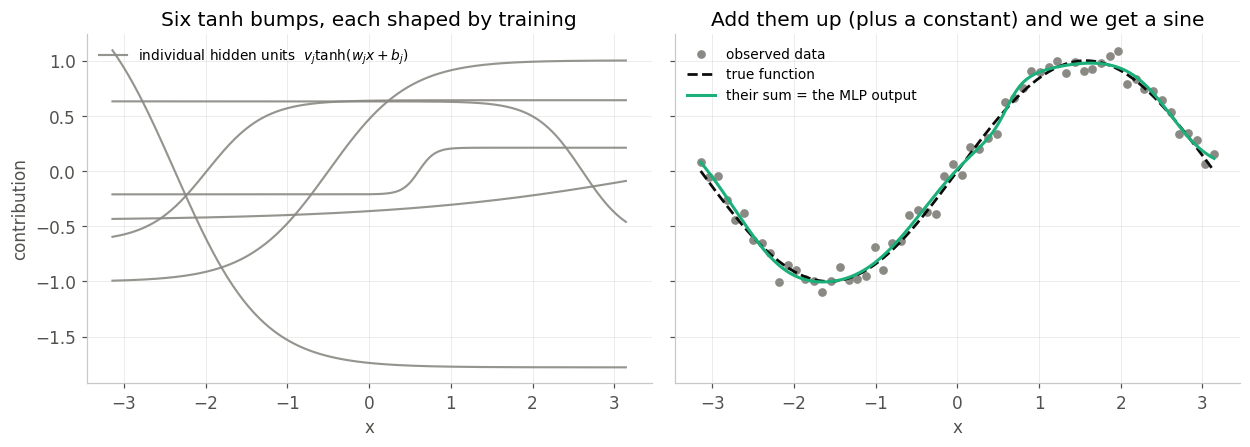

learned parameters of the 6 hidden units:
  unit 0:  w = -1.02,  b = -0.51,  v = -1.00
  unit 1:  w = -1.43,  b = -2.84,  v = -0.64
  unit 2:  w = -0.29,  b = +1.13,  v = -0.45
  unit 3:  w = -5.05,  b = +3.07,  v = -0.21
  unit 4:  w = +0.94,  b = +2.24,  v = -1.78
  unit 5:  w = -1.74,  b = +4.54,  v = +0.63


In [40]:
torch.manual_seed(3)
mlp_small = make_mlp(width=6)
train(mlp_small, xs_t, ys_t, epochs=8000, lr=0.01)

W1 = mlp_small[0].weight.detach().numpy().ravel()   # w_j
B1 = mlp_small[0].bias.detach().numpy().ravel()     # b_j
W2 = mlp_small[2].weight.detach().numpy().ravel()   # v_j
B2 = mlp_small[2].bias.item()                       # c

pieces = np.array([v * np.tanh(w * xs_grid + b) for w, b, v in zip(W1, B1, W2)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)

# The six neurons are interchangeable parts, not six meaningful categories,
# so they all share one recessive colour with a single legend entry.
for k, p in enumerate(pieces):
    ax1.plot(xs_grid, p, color=C_DATA, lw=1.4, alpha=0.9,
             label="individual hidden units  $v_j\\tanh(w_jx+b_j)$" if k == 0 else None)
ax1.set(xlabel="x", ylabel="contribution",
        title="Six tanh bumps, each shaped by training")
ax1.legend(loc="upper left", fontsize=9)

ax2.scatter(x_sin, y_sin, s=22, color=C_DATA, label="observed data")
ax2.plot(xs_grid, np.sin(xs_grid), color=C_TRUE, ls="--", lw=1.8, label="true function")
ax2.plot(xs_grid, pieces.sum(axis=0) + B2, color=C_MLP, label="their sum = the MLP output")
ax2.set(xlabel="x", title="Add them up (plus a constant) and we get a sine")
ax2.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

print("learned parameters of the 6 hidden units:")
for j, (wj, bj, vj) in enumerate(zip(W1, B1, W2)):
    print(f"  unit {j}:  w = {wj:+.2f},  b = {bj:+.2f},  v = {vj:+.2f}")

That is the secret of a neural network on this problem, it is just **a learned basis expansion**. The polynomial fit used a basis somebody chose in advance ($1, x, x^2, \dots$); the MLP used a basis it shaped itself to suit the data. This is why the *universal approximation theorem* is true, with enough bumps you can build any continuous function on a bounded interval, and also why "enough" is the whole difficulty.


---
# 4. Two ways this goes wrong

This can however not always go well. Here are two examples.

## 4.1 Extrapolation: outside the training range, all bets are off

We trained on $[-\pi, \pi]$. Sine is periodic, so *we* know what happens at $x = 3\pi$. The network has not seen this and there is nothing making it periodic. We can even predict exactly what it will do: as $x \to \pm\infty$ every $\tanh(w_j x + b_j)$ saturates at $\pm 1$, so the whole network flattens out to a constant.

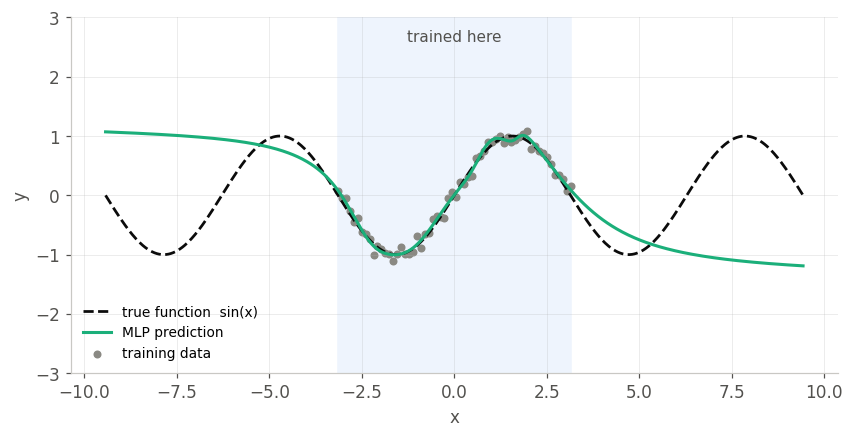

In [46]:
x_wide = np.linspace(-3 * np.pi, 3 * np.pi, 600)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.axvspan(-np.pi, np.pi, color="#eef4fd", zorder=0)
ax.text(0, 2.6, "trained here", ha="center", fontsize=10, color="#52514e")
ax.plot(x_wide, np.sin(x_wide), color=C_TRUE, ls="--", lw=1.8, label="true function  sin(x)")
ax.plot(x_wide, predict(mlp_sin, x_wide), color=C_MLP, label="MLP prediction")
ax.scatter(x_sin, y_sin, s=18, color=C_DATA, label="training data")
ax.set(xlabel="x", ylabel="y", ylim=(-3, 3))
ax.legend(loc="lower left", fontsize=9)
plt.show()

This means that a neural network will give us **a fitted model about the region you sampled.** If we need behaviour outside that region, you need to add this either through more data, or through structure baked into the model (periodic features, a known conservation law, a physical constraint).

## 4.2 Overfitting: too much capacity, too little data

We met overfitting already but here we will make it more extreme. We give a large network only **12** noisy points and train it too hard: it has far more than enough freedom to thread its way through every single one, driving the *training* loss to zero while inventing the function in between.

In [48]:
# A deliberately small, noisy training set - and a large test set the model never sees.
rng_few = np.random.default_rng(7)
x_few = np.sort(rng_few.uniform(-np.pi, np.pi, 12))
y_few = np.sin(x_few) + rng_few.normal(0, 0.15, 12)
x_test = np.sort(rng_few.uniform(-np.pi, np.pi, 200))
y_test = np.sin(x_test) + rng_few.normal(0, 0.15, 200)

xf, yf = T(x_few), T(y_few)

torch.manual_seed(0)
big = make_mlp(width=128, depth=3)         # far more capacity than 12 points can justify
h_big, _ = train(big, xf, yf, epochs=12000, lr=0.001)

torch.manual_seed(0)
small = make_mlp(width=3)                  # deliberately modest: 10 parameters
h_small, _ = train(small, xf, yf, epochs=4000, lr=0.01)

print(f"{'model':<22}{'params':>8}{'train MSE':>12}{'test MSE':>11}")
for name, m, h in [("big  (3 x 128)", big, h_big), ("small (1 x 3)", small, h_small)]:
    print(f"{name:<22}{n_params(m):>8}{h[-1]:>12.5f}{mse(predict(m, x_test), y_test):>11.5f}")

model                   params   train MSE   test MSE
big  (3 x 128)           33409     0.00000    0.46475
small (1 x 3)               10     0.01030    0.06695


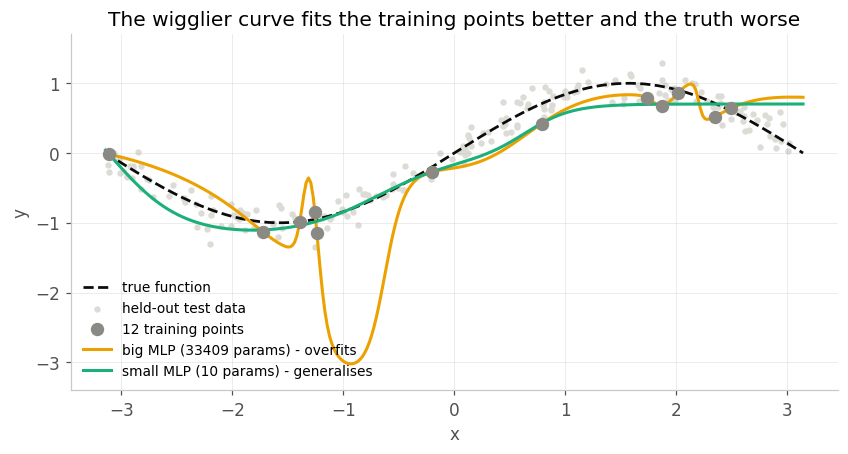

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(xs_grid, np.sin(xs_grid), color=C_TRUE, ls="--", lw=1.8, label="true function")
ax.scatter(x_test, y_test, s=10, color="#dcdbd6", zorder=1, label="held-out test data")
ax.scatter(x_few, y_few, s=60, color=C_DATA, zorder=3, label="12 training points")
ax.plot(xs_grid, predict(big, xs_grid), color=C_POLY, zorder=2,
        label=f"big MLP ({n_params(big)} params) - overfits")
ax.plot(xs_grid, predict(small, xs_grid), color=C_MLP, zorder=2,
        label=f"small MLP ({n_params(small)} params) - generalises")
ax.set(xlabel="x", ylabel="y", ylim=(-3.4, 1.7))
ax.legend(loc="lower left", fontsize=9)
plt.show()

The yellow curve passes exactly through the training dots, training loss essentially zero, a "perfect" fit, but it is obviously the worse model.

---
# Part 5 — Summary

| Question | Answer |
|---|---|
| What is fitting? | choosing parameters $\theta$ that minimise a loss $L(\theta)$ |
| What is gradient descent? | repeatedly step downhill: $\theta \leftarrow \theta - \eta\nabla_\theta L$ |
| What does PyTorch add? | autograd computes $\nabla_\theta L$ for *any* model you can write |
| Why a hidden layer? | without the nonlinearity, layers collapse into one straight line |
| What does an MLP really do? | builds a **learned basis**, a sum of shaped `tanh` bumps |
| When is a linear model better? | whenever the truth is (nearly) linear: exact, instant, interpretable |
| Model too rigid | **underfitting** high train *and* test loss; enlarge the model family |
| Model too flexible | **overfitting** low train loss, high test loss; shrink it or get more data |
| Outside the training range | predictions are invented; interpolation ≠ extrapolation |

